# Libraries

In [20]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# EDA

## Load Dataset

In [21]:
# Load the employee burnout dataset from Hugging Face
dataset = load_dataset('BrotherTony/employee-burnout-turnover-prediction-800k')

In [22]:
df = pd.DataFrame(dataset['train'])

In [23]:
print(f"Dataset shape: {df.shape}")
print(f"\nDataset info:")
print(df.info())

Dataset shape: (849999, 31)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 849999 entries, 0 to 849998
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   employee_id                     849999 non-null  object 
 1   role                            849999 non-null  object 
 2   job_level                       849999 non-null  object 
 3   department                      849999 non-null  object 
 4   tenure_months                   849999 non-null  int64  
 5   salary                          849999 non-null  float64
 6   performance_score               849999 non-null  float64
 7   satisfaction_score              849999 non-null  float64
 8   workload_score                  849999 non-null  float64
 9   team_sentiment                  849999 non-null  float64
 10  recent_feedback                 849999 non-null  object 
 11  communication_patterns          849

In [24]:
cols_to_drop = [
    'employee_id', 
    'left_company', 
    'turnover_reason', 
    'turnover_probability_generated', 
    'persona_name',
    'risk_factors_summary',
    'technical_skills',
    'soft_skills',
    'role',
    'recent_feedback',
    'communication_patterns',
    'department'
    ]
df.drop(columns=cols_to_drop, inplace=True)

We drop employee_id as it is a unique identifier.  
We drop left_company, turnover_reason, turnover_probability_generated as we aim to predict stress level before they leave.    
We drop risk_factors_summary as it may cause data leakage with stress level.    
We drop technical_skills, soft_skills, role, department as different companies have different skill requirements and department structures, making it difficult to generalize the model.  
We drop recent_feedback as the comments are gibberish.  
We drop communication_patterns, persona_name as they are arbitrary.

## Correlation Analysis

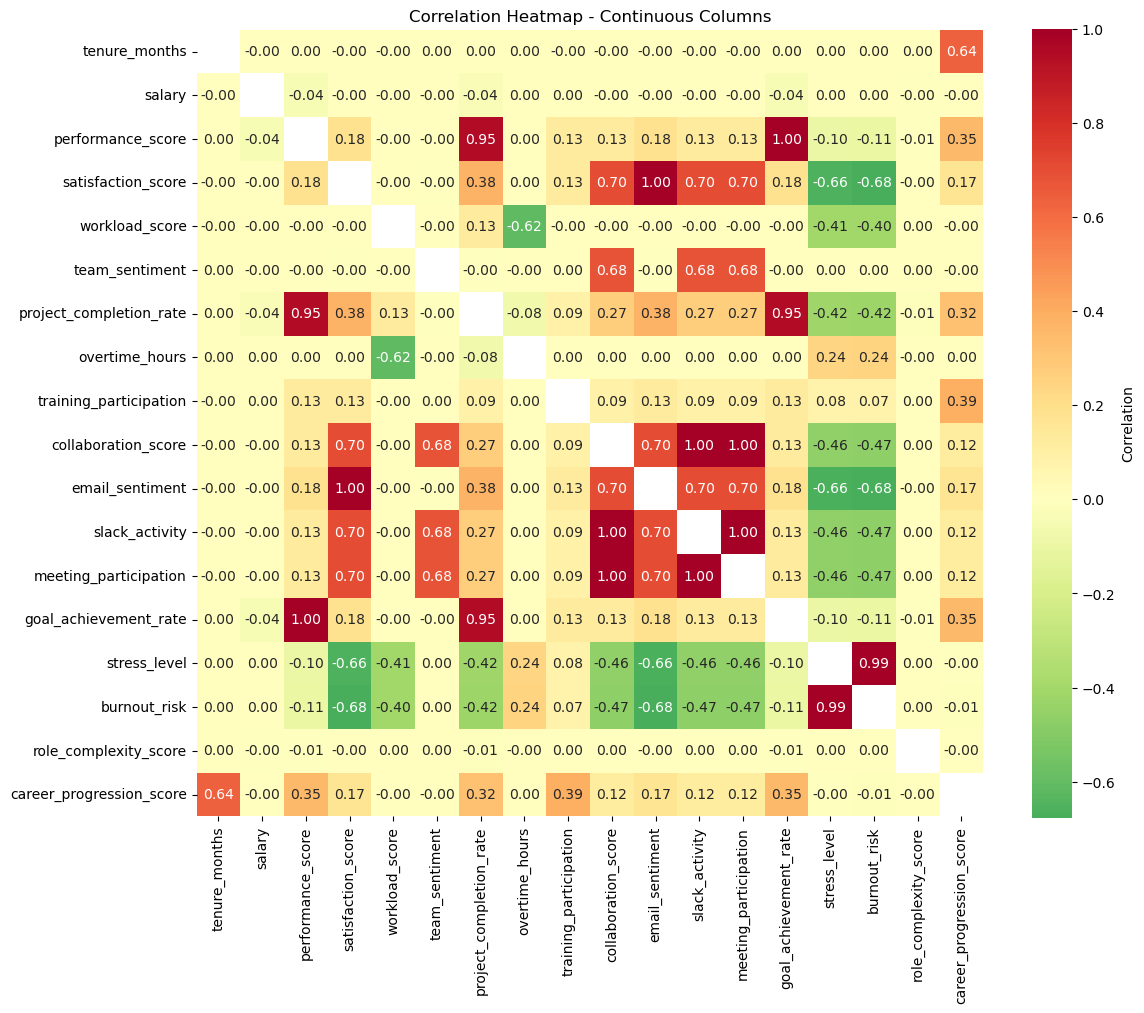

In [25]:
# Correlation heatmap for continuous columns
float_cols = df.select_dtypes(include=['float64', 'float32', 'int64', 'int32']).columns
correlation_matrix = df[float_cols].corr()

# Mask diagonal (self-correlations)
mask = np.eye(correlation_matrix.shape[0], dtype=bool)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn_r', center=0, fmt='.2f', square=True, cbar_kws={'label': 'Correlation'}, mask=mask)
plt.title('Correlation Heatmap - Continuous Columns')
plt.tight_layout()
plt.show()

goal_achievement_rate, performance_score, project_completion_rate have high correlation, we select performance_score.  
meeting_participation, collaboration_score, slack_acitivity have high correlation, we select collaboration_score.  
email_sentiment and satisfaction_score have high correlation, we select satisfaction_score.  
stress_level and burnout_risk have high correlation, we select stress_level.

In [ ]:
cols_to_drop = [
    'goal_achievement_rate',
    'project_completion_rate',
    'meeting_participation',
    'slack_activity',
    'email_sentiment',
    'burnout_risk'
]
df.drop(columns=cols_to_drop, inplace=True)

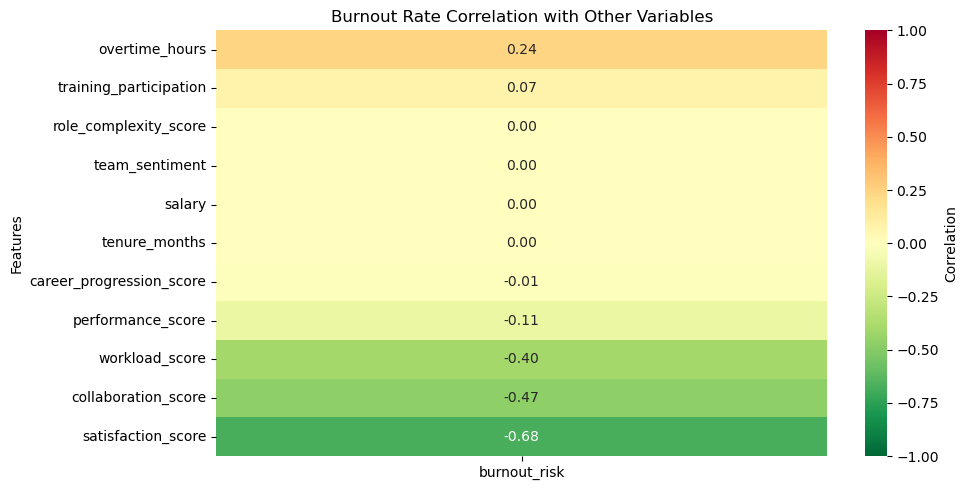

In [ ]:
# Stress Level correlation heatmap with other variables
float_cols = df.select_dtypes(include=['float64', 'float32', 'int64', 'int32']).columns
correlation_matrix = df[float_cols].corr()
stress_corr = correlation_matrix['stress_level'].drop('stress_level').sort_values(ascending=False)
stress_corr_df = stress_corr.to_frame()

plt.figure(figsize=(10, 5))
sns.heatmap(stress_corr_df, annot=True, cmap='RdYlGn_r', center=0, fmt='.2f', cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1)
plt.title('Stress Level Correlation with Other Variables')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [28]:
# Display all columns
pd.set_option('display.max_columns', None)
df.head(3)

,job_level,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,overtime_hours,training_participation,collaboration_score,burnout_risk,role_complexity_score,career_progression_score
0,Mid,169,79704.579059,0.632482,0.623746,0.758117,0.662335,0.0,0.044373,0.492131,0.866643,0.2,1.000000
1,Manager,54,29694.288831,0.538587,0.982556,0.788416,0.934661,0.0,0.314858,0.981394,0.218996,0.2,1.000000
2,Entry,1,62208.470185,0.624656,0.767200,0.697617,0.888559,0.0,0.744900,0.701138,0.541531,0.2,0.836495


# Data Preprocessing

In [29]:
# Strip whitespace and check for empty strings
empty_string_counts = (df.applymap(lambda x: isinstance(x, str) and x.strip() == '')).sum()
# Replace empty strings with NaN
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

In [30]:
df.isnull().sum()

job_level                   0
tenure_months               0
salary                      0
performance_score           0
satisfaction_score          0
workload_score              0
team_sentiment              0
overtime_hours              0
training_participation      0
collaboration_score         0
burnout_risk                0
role_complexity_score       0
career_progression_score    0
dtype: int64

In [ ]:
# Randomly mask feature values with NaN before one-hot encoding
rng = np.random.default_rng(42)
feature_cols = df.columns.drop('stress_level')
maskable_cols = feature_cols.tolist()

def mask_row(row):
    if len(maskable_cols) < 2 or rng.random() > 0.3:
        return row

    n_cols = len(maskable_cols)
    low_max = min(2, n_cols - 1)
    high_min = max(3, int(np.ceil(n_cols * 0.5)))
    high_min = min(high_min, n_cols - 1)

    if high_min <= low_max:
        mask_count = int(rng.integers(1, n_cols))
    else:
        if rng.random() < 0.5:
            mask_count = int(rng.integers(1, low_max + 1))
        else:
            mask_count = int(rng.integers(high_min, n_cols))

    cols_to_mask = rng.choice(maskable_cols, size=mask_count, replace=False)
    row = row.copy()
    row[cols_to_mask] = np.nan
    return row

df = df.apply(mask_row, axis=1)

print(f'Masked rows: {(df[maskable_cols].isna().any(axis=1)).sum()}')
print(f'Total rows: {len(df)}')

Masked rows: 254765
Total rows: 849999


In [32]:
df.isnull().sum()

job_level                   106231
tenure_months               106350
salary                      106288
performance_score           106154
satisfaction_score          106348
workload_score              106025
team_sentiment              106080
overtime_hours              106514
training_participation      106158
collaboration_score         106225
burnout_risk                     0
role_complexity_score       106142
career_progression_score    106333
dtype: int64

In [33]:
# One-hot encode categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
list(df.columns)

['tenure_months',
 'salary',
 'performance_score',
 'satisfaction_score',
 'workload_score',
 'team_sentiment',
 'overtime_hours',
 'training_participation',
 'collaboration_score',
 'burnout_risk',
 'role_complexity_score',
 'career_progression_score',
 'job_level_Lead',
 'job_level_Manager',
 'job_level_Mid',
 'job_level_Senior']

In [ ]:
# Split the dataframe into train, validation, and test sets for stress level prediction
# 80% train, 10% validation, 10% test
X = df.drop(columns=['stress_level'])
y = df['stress_level']

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print(f'Train shape: {X_train.shape}, {y_train.shape}')
print(f'Validation shape: {X_val.shape}, {y_val.shape}')
print(f'Test shape: {X_test.shape}, {y_test.shape}')

Train shape: (679999, 15), (679999,)
Validation shape: (85000, 15), (85000,)
Test shape: (85000, 15), (85000,)


# Models

## Baseline Model

In [35]:
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error

baseline_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)
baseline_model.fit(X_train, y_train)

val_pred = baseline_model.predict(X_val)
baseline_rmse = root_mean_squared_error(y_val, val_pred)

print(f'Baseline validation RMSE: {baseline_rmse:.4f}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2813
[LightGBM] [Info] Number of data points in the train set: 679999, number of used features: 15
[LightGBM] [Info] Start training from score 0.736274
Baseline validation RMSE: 0.1552


## Ablation Tests

In [41]:
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error

ablation_results = {}
job_level_cols = [col for col in X_train.columns if col.startswith('job_level_')]

feature_groups = [(col, [col]) for col in X_train.columns if col not in job_level_cols]
if job_level_cols:
    feature_groups.append(('job_level', job_level_cols))

for feature_name, cols_to_remove in feature_groups:
    X_train_ablation = X_train.drop(columns=cols_to_remove)
    X_val_ablation = X_val.drop(columns=cols_to_remove)

    ablation_model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1
)
    ablation_model.fit(X_train_ablation, y_train)

    val_pred = ablation_model.predict(X_val_ablation)
    ablation_rmse = root_mean_squared_error(y_val, val_pred)

    ablation_results[feature_name] = {
        'removed_columns': cols_to_remove,
        'rmse': ablation_rmse,
        'performance_drop': ablation_rmse - baseline_rmse,
        'performance_drop_pct': ((ablation_rmse - baseline_rmse) / baseline_rmse) * 100
    }

ablation_results

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005545 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2558
[LightGBM] [Info] Number of data points in the train set: 679999, number of used features: 14
[LightGBM] [Info] Start training from score 0.736274
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2558
[LightGBM] [Info] Number of data points in the train set: 679999, number of used features: 14
[LightGBM] [Info] Start training from score 0.736274
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005003 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not eno

{'tenure_months': {'removed_columns': ['tenure_months'],
  'rmse': 0.1628078601616034,
  'performance_drop': 0.0076280133814259354,
  'performance_drop_pct': 4.91559538155204},
 'salary': {'removed_columns': ['salary'],
  'rmse': 0.15535193228500466,
  'performance_drop': 0.0001720855048271963,
  'performance_drop_pct': 0.1108942355581565},
 'performance_score': {'removed_columns': ['performance_score'],
  'rmse': 0.1649283590453068,
  'performance_drop': 0.00974851226512935,
  'performance_drop_pct': 6.282073650284476},
 'satisfaction_score': {'removed_columns': ['satisfaction_score'],
  'rmse': 0.1711716529160148,
  'performance_drop': 0.01599180613583734,
  'performance_drop_pct': 10.305336980059526},
 'workload_score': {'removed_columns': ['workload_score'],
  'rmse': 0.1791578149962769,
  'performance_drop': 0.023977968216099432,
  'performance_drop_pct': 15.451728245398911},
 'team_sentiment': {'removed_columns': ['team_sentiment'],
  'rmse': 0.156810048338784,
  'performance_dro

,removed_columns,rmse,performance_drop,performance_drop_pct
workload_score,[workload_score],0.179158,0.023978,15.451728
satisfaction_score,[satisfaction_score],0.171172,0.015992,10.305337
career_progression_score,[career_progression_score],0.167071,0.011892,7.663098
performance_score,[performance_score],0.164928,0.009749,6.282074
tenure_months,[tenure_months],0.162808,0.007628,4.915595
collaboration_score,[collaboration_score],0.160277,0.005097,3.284752
training_participation,[training_participation],0.160116,0.004936,3.180785
overtime_hours,[overtime_hours],0.156958,0.001778,1.145689
team_sentiment,[team_sentiment],0.156810,0.001630,1.050524
job_level,"[job_level_Lead, job_level_Manager, job_level_...",0.155533,0.000353,0.227313


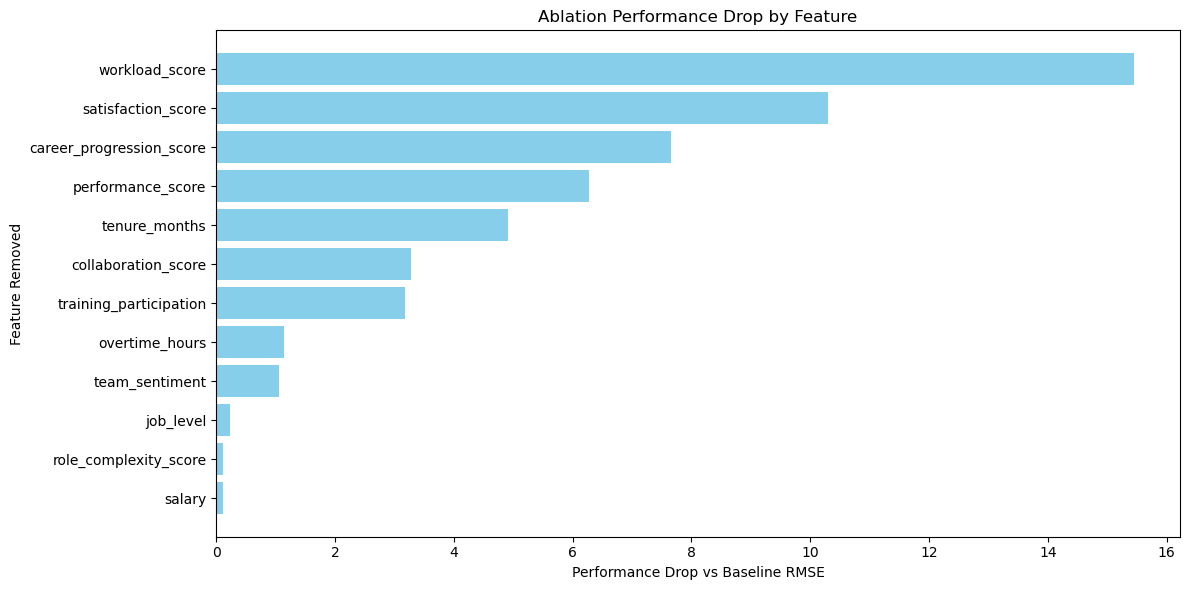

In [42]:
ablation_df = pd.DataFrame.from_dict(ablation_results, orient='index')
ablation_df = ablation_df.sort_values('performance_drop_pct', ascending=False)

display(ablation_df)

plt.figure(figsize=(12, max(6, 0.35 * len(ablation_df))))
plt.barh(ablation_df.index.astype(str), ablation_df['performance_drop_pct'], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Performance Drop vs Baseline RMSE')
plt.ylabel('Feature Removed')
plt.title('Ablation Performance Drop by Feature')
plt.tight_layout()
plt.show()

## Evaluate performance by dropping features

In [44]:
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error

def evaluate_drop_columns(drop_cols):
    # Keep original data intact by working on copies of train/val features only
    drop_cols = list(drop_cols)
    expanded_drop_cols = []

    for col in drop_cols:
        if col == 'job_level':
            expanded_drop_cols.extend([c for c in X_train.columns if c.startswith('job_level_')])
        else:
            expanded_drop_cols.append(col)

    # Remove duplicates while preserving order
    expanded_drop_cols = list(dict.fromkeys(expanded_drop_cols))

    missing_cols = [c for c in expanded_drop_cols if c not in X_train.columns]
    valid_drop_cols = [c for c in expanded_drop_cols if c in X_train.columns]

    X_train_try = X_train.drop(columns=valid_drop_cols).copy()
    X_val_try = X_val.drop(columns=valid_drop_cols).copy()

    model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_try, y_train)
    val_pred_try = model.predict(X_val_try)
    rmse_try = root_mean_squared_error(y_val, val_pred_try)

    result = {
        'requested_drop_cols': drop_cols,
        'actual_drop_cols': valid_drop_cols,
        'missing_cols': missing_cols,
        'rmse': rmse_try,
        'performance_drop': rmse_try - baseline_rmse
    }
    return result

# Example: edit this list and rerun the cell
cols_to_try = ['job_level', 'role_complexity_score', 'salary']
trial_result = evaluate_drop_columns(cols_to_try)
trial_result

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005180 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 679999, number of used features: 9
[LightGBM] [Info] Start training from score 0.736274


{'requested_drop_cols': ['job_level', 'role_complexity_score', 'salary'],
 'actual_drop_cols': ['job_level_Lead',
  'job_level_Manager',
  'job_level_Mid',
  'job_level_Senior',
  'role_complexity_score',
  'salary'],
 'missing_cols': [],
 'rmse': 0.1553392359498132,
 'performance_drop': 0.0001593891696357319}

## XGBoost

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
 )
xgb_model.fit(X_train, y_train)

xgb_val_pred = xgb_model.predict(X_val)
xgb_rmse = root_mean_squared_error(y_val, xgb_val_pred)
xgb_performance_drop = baseline_rmse - xgb_rmse

print(f'XGBoost validation RMSE: {xgb_rmse:.4f}')
print(f'Performance drop vs baseline RMSE: {xgb_performance_drop:.4f}')

## CatBoost

In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import root_mean_squared_error

cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
 )
cat_model.fit(X_train, y_train)

cat_val_pred = cat_model.predict(X_val)
cat_rmse = root_mean_squared_error(y_val, cat_val_pred)
cat_performance_drop = baseline_rmse - cat_rmse

print(f'CatBoost validation RMSE: {cat_rmse:.4f}')
print(f'Performance drop vs baseline RMSE: {cat_performance_drop:.4f}')